In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
from DataManager import DataManager

control = DataManager(["LP","DV"], "TrozoC.txt")
control

DataManager(filename='TrozoC.txt', channels=['LP', 'DV'], n_recordings=198, recording_length=100000)

In [2]:
control.describe()

,mean,std,min,max,median,mean_max,n_above_mean_max,n_at_or_below_mean_max
channel,,,,,,,,
LP,-2.492187e-08,0.082140,-0.710144,0.934448,0.000305,0.318146,157786,19642214
DV,4.385757e-02,0.032878,-2.170715,1.351624,0.043640,0.199236,159180,19640820


In [3]:
control.describe_recording(24)

,mean,std,min,max,median,mean_max,n_above_mean_max,n_at_or_below_mean_max
channel,,,,,,,,
LP,-0.000005,0.084456,-0.498047,0.721436,0.000305,0.360716,763,99237
DV,0.043642,0.030689,-0.152283,0.386353,0.043335,0.214997,659,99341


(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: ylabel='LP'>, <Axes: xlabel='Time (ms)', ylabel='DV'>],
       dtype=object))

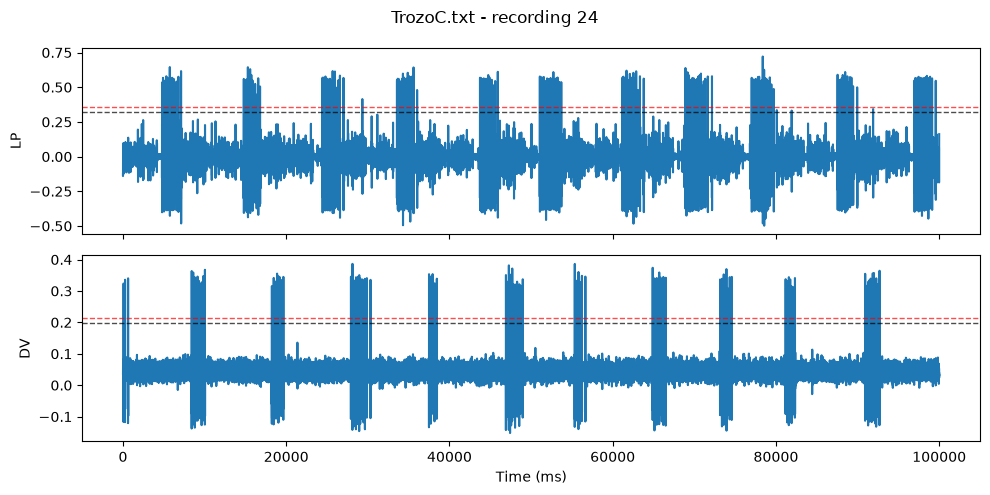

In [4]:
control.plot_channels(24,show_mean_max=True)

In [5]:
event_time_window = 20
kobes_record = control.discretize_recording(index=24,event_time_window=event_time_window)
kobes_record[:33]

array([[0, 0],
       [0, 0],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 1],
       [0, 0]])

<Axes: title={'center': 'TrozoC.txt - recording 24'}, xlabel='Time (ms)', ylabel='Potential'>

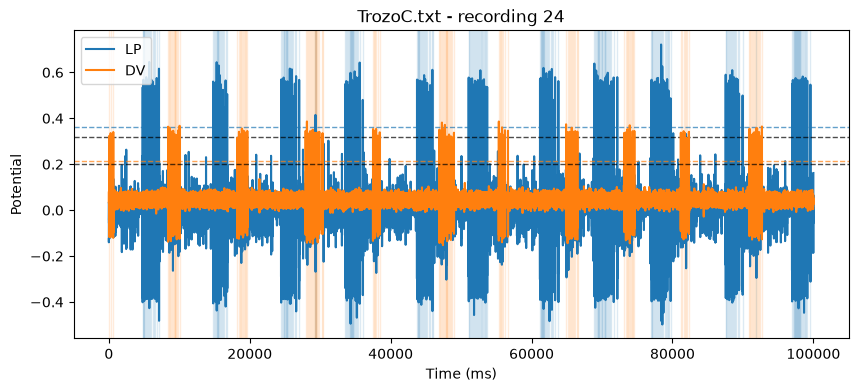

In [6]:
control.plot_recording(24,show_mean_max=True, event_time_window=20)

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: ylabel='LP'>, <Axes: xlabel='Time (ms)', ylabel='DV'>],
       dtype=object))

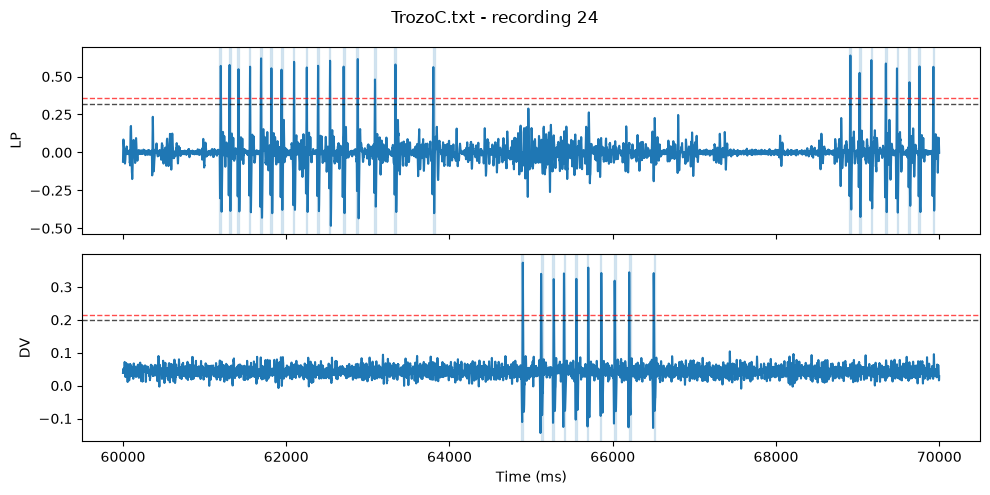

In [7]:
control.plot_channels(24,show_mean_max=True, event_time_window=20, zoom=(60000, 70000))

In [17]:
from DataWidget import crear_widget

crear_widget(control)

print("-")

-


In [9]:
gaba = DataManager(["LP","DV","Gaba"], "TrozoG.txt")

crear_widget(gaba)

print("-")

-


In [16]:
from event_experiment import EventExperiment
import numpy as np

event_time_window = 20
discretize_record = control.discretize_recording(index=0,event_time_window=event_time_window)

for i in np. arange(1,10):
    discretize_record = np.concat(discretize_record,control.discretize_recording(index=i,event_time_window=event_time_window))

seq = discretize_record[:,0]
exp = EventExperiment(seq, word_length=2)

print(exp.entropy_block)
print(exp.entropy_conditional)
print(exp.prob((0, 1)))
print(exp.cond_prob(1, (0,)))
print(exp.chain_prob((0, 1, 0)))
exp.save("experiment.json")
restored = EventExperiment.load("experiment.json")

TypeError: only integer scalar arrays can be converted to a scalar index

In [8]:
from event_experiment import EventExperiment
from DataManager import DataManager

control = DataManager(["LP","DV"], "TrozoC.txt")
exp = EventExperiment(manager=control, word_length=2,)
print(exp.entropy_block)
print(exp.entropy_conditional)
print(exp.prob((0, 1)))
print(exp.cond_prob(1, (0,)))
print(exp.chain_prob((0, 1, 0)))
exp.save("experiment.json")
restored = EventExperiment.load("base_control_exp.json")

KeyboardInterrupt: 